In [18]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import utilities as u

<div class="alert alert-success">
    <h1>SVD via ED</h1>
    (Singular Value Decomposition via Eigendecomposition)
</div>


Let  
$$
A \in \mathbb{R}^{m \times n}
$$
be a real matrix. The **Singular Value Decomposition (SVD)** of $A$ is given by
$$
A = U D V^{\top},
$$

where

- $U \in \mathbb{R}^{m \times m}$ is an orthogonal matrix  
- $V \in \mathbb{R}^{n \times n}$ is an orthogonal matrix  
- $D \in \mathbb{R}^{m \times n}$ is a diagonal matrix of singular values  

Explicitly,
$$
D =
\begin{pmatrix}
\sigma_1 & 0 & \cdots & 0 \\
0 & \sigma_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \sigma_r \\
0 & 0 & \cdots & 0 \\
\vdots & \vdots &        & \vdots
\end{pmatrix},
\quad
\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_r > 0,
$$
with $r = \operatorname{rank}(A)$.

---

### Eigendecomposition Connection

Consider the symmetric matrix
$$
A^{\top} A \in \mathbb{R}^{n \times n}.
$$

Using the SVD of $A$, we obtain
$$
A^{\top} A
= (U D V^{\top})^{\top}(U D V^{\top})
= V D^{\top} D V^{\top}.
$$

Define
$$
S = D^{\top} D =
\begin{pmatrix}
\sigma_1^2 & 0 & \cdots & 0 \\
0 & \sigma_2^2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \sigma_r^2 \\
0 & 0 & \cdots & 0 \\
\vdots & \vdots &        & \vdots
\end{pmatrix}
\in \mathbb{R}^{n \times n}.
$$

Hence,
$$
A^{\top} A = V S V^{\top},
$$
which is the **eigendecomposition** of $A^{\top} A$.

- The columns of $V$ are eigenvectors of $A^{\top} A$
- The eigenvalues of $A^{\top} A$ are $\sigma_1^2, \ldots, \sigma_r^2$

---

### Recovering $U$

For nonzero singular values, define
$$
T = \operatorname{diag}(\sigma_1^{-1}, \ldots, \sigma_r^{-1}) \in \mathbb{R}^{m \times n}.
$$

Then the left singular vectors are obtained by
$$
U = A V T.
$$

Equivalently, for each $i = 1,\ldots,r$,
$$
u_i = \frac{1}{\sigma_i} A v_i.
$$

---

### Remark

- $A^{\top} A$ is symmetric and positive semidefinite  
- Its eigendecomposition directly yields the **right singular vectors** and **singular values**  
- The SVD can therefore be computed via eigendecomposition of $A^{\top} A$ (though this is not the most numerically stable method in practice)



---
---
---

<div class="alert alert-success">
    Uploading image to work with
</div>

RGB
(667, 1000)


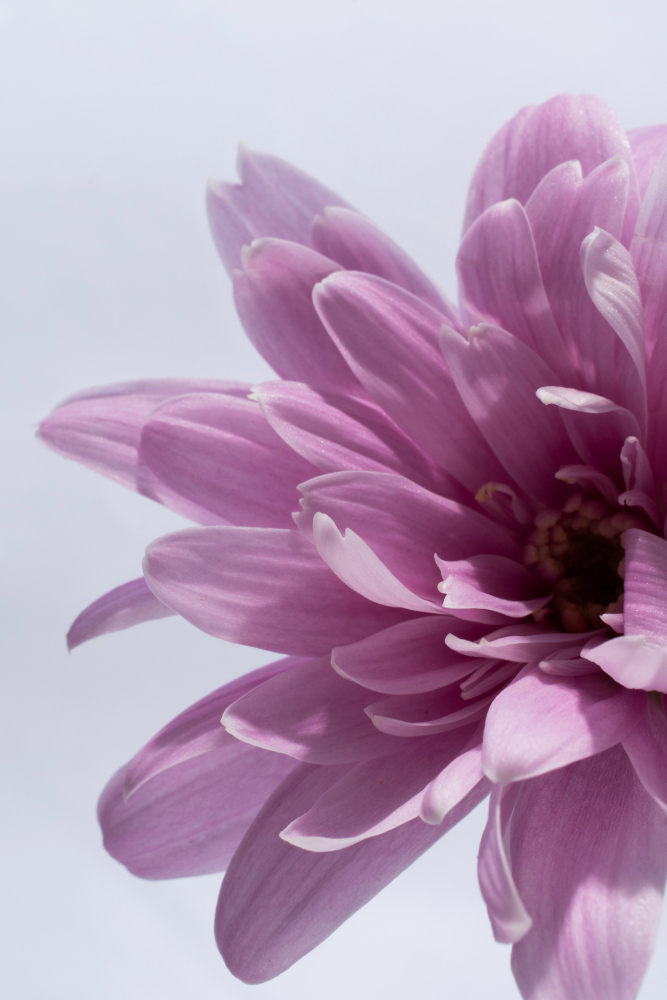

In [19]:
matrix = Image.open('C.jpg')

print(matrix.mode)
print(matrix.size)
matrix

In [20]:
r_c, g_c, b_c = matrix.split()

R = np.array(r_c).astype(np.float64)
G = np.array(g_c).astype(np.float64)
B = np.array(b_c).astype(np.float64)

data = {
    " ": ['Shape', 'type', 'datatype'],
    "R": [R.shape, type(R), R.dtype],
    "G": [G.shape, type(G), G.dtype],
    "B": [B.shape, type(B), B.dtype]
}

df = pd.DataFrame(data)
df

,,R,G,B
0,Shape,"(1000, 667)","(1000, 667)","(1000, 667)"
1,type,<class 'numpy.ndarray'>,<class 'numpy.ndarray'>,<class 'numpy.ndarray'>
2,datatype,float64,float64,float64


<div class="alert alert-success">
    Errors
</div>

In [24]:
custom_ED = np.sort(u.Eigendecomposition_via_QR(R.T @ R, tol=1e-23)[0])
numpy_ED  = np.sort(np.linalg.eigvals(R.T @ R))
e = np.max(np.abs(custom_ED - numpy_ED))
print("max error:", e)

max error: 3.814697265625e-06


<div class="alert alert-success">
    SVD on each channel
</div>

In [25]:
R_U, R_D, R_V = u.svd(R)
G_U, G_D, G_V = u.svd(G)
B_U, B_D, B_V = u.svd(B)

<div class="alert alert-success">
    Selecting k most important eigenvectors and reconstructing the compressed image
</div>

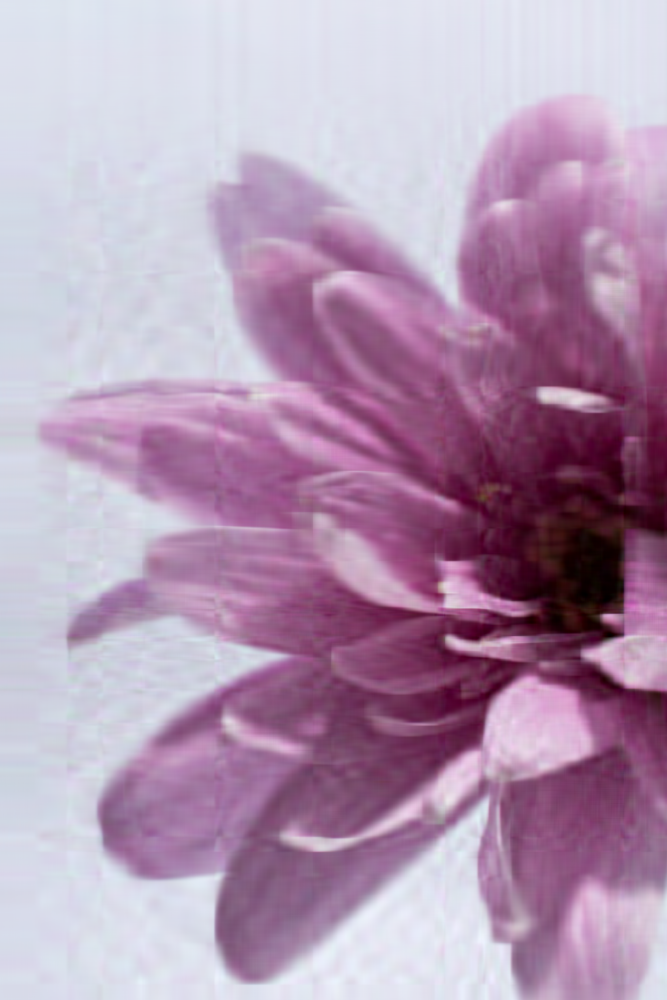

In [26]:
k = 30

svd_R = R_U[:,:k] @ R_D[:k,:k] @ R_V.T[:k,:]
svd_G = G_U[:,:k] @ G_D[:k,:k] @ G_V.T[:k,:]
svd_B = B_U[:,:k] @ B_D[:k,:k] @ B_V.T[:k,:]

R_svd = torch.clamp(svd_R, 0, 255).to(torch.uint8).cpu().numpy()
G_svd = torch.clamp(svd_G, 0, 255).to(torch.uint8).cpu().numpy()
B_svd = torch.clamp(svd_B, 0, 255).to(torch.uint8).cpu().numpy()

# Recombination into an RGB image
rgb_array = np.dstack((R_svd, G_svd, B_svd))
rgb_img = Image.fromarray(rgb_array, mode="RGB")
rgb_img

<div class="alert alert-success">
    Grid of different k-values and reconstructions
</div>

In [27]:
def scaling(x, beta, alpha):
    return np.floor(beta * np.exp(x * np.log(alpha / beta) / alpha))

σ =
[[  1.   2.   5.]
 [ 11.  25.  58.]
 [131. 296. 666.]]


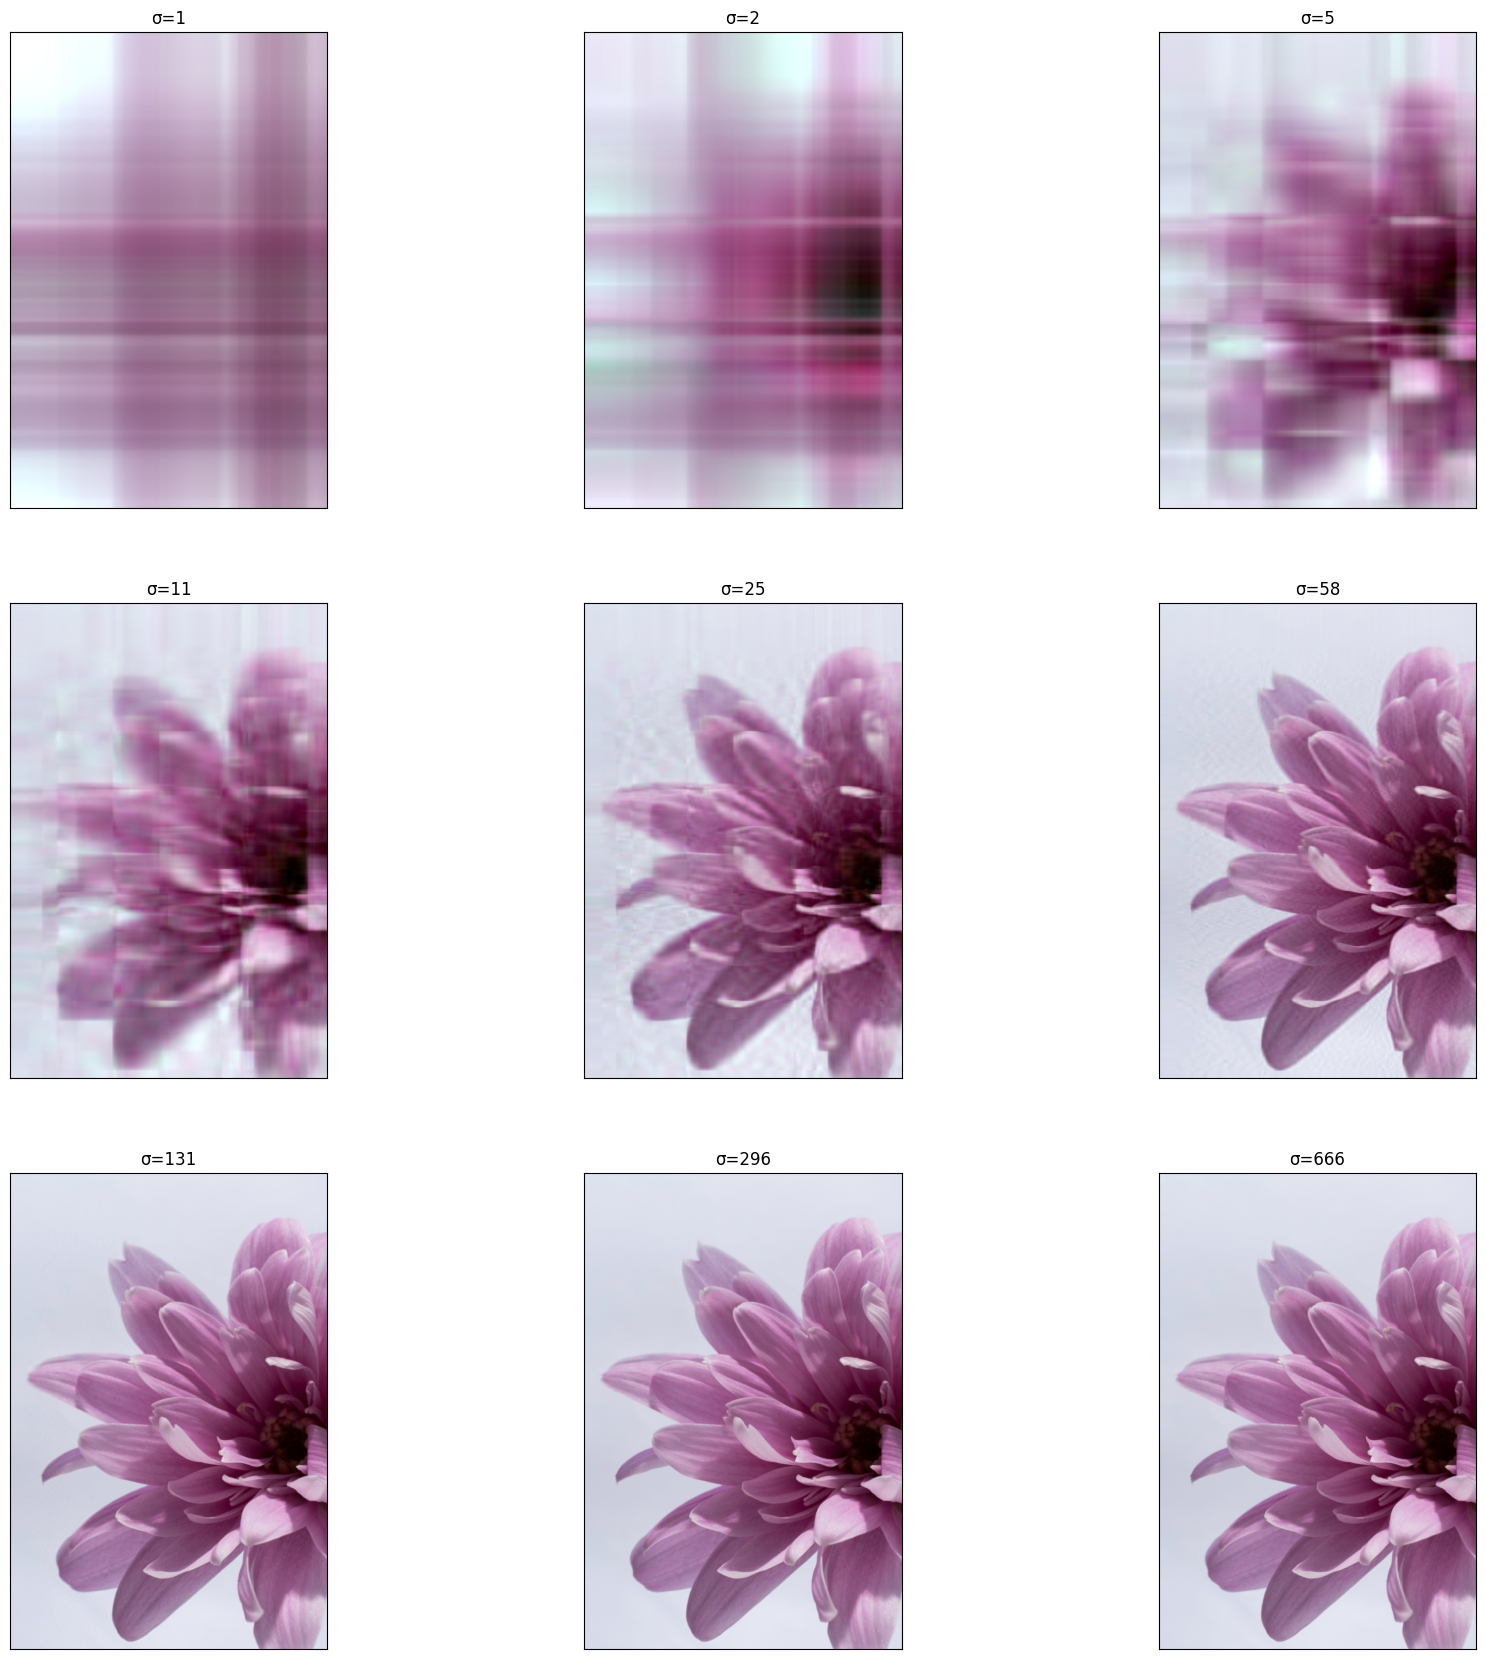

In [32]:
a = 3
b = 3
rgb_array = np.dstack((R_svd, G_svd, B_svd))

total = a*b
sigma = R_D.shape[0]

x = np.linspace(1, sigma, total)
l = scaling(x, 1, sigma)
l_m = np.reshape(l, (a,b))
print(f'σ =\n{l_m}')

fig, canvas = plt.subplots(nrows=a, ncols=b, figsize=(7*b,7*a))
for i in range(a):
    for j in range(b):
        k = int(l_m[i,j])

        svd_R = R_U[:,:k] @ R_D[:k,:k] @ R_V.T[:k,:]
        svd_G = G_U[:,:k] @ G_D[:k,:k] @ G_V.T[:k,:]
        svd_B = B_U[:,:k] @ B_D[:k,:k] @ B_V.T[:k,:]
        
        R_svd = torch.clamp(svd_R, 0, 255).to(torch.uint8).cpu().numpy()
        G_svd = torch.clamp(svd_G, 0, 255).to(torch.uint8).cpu().numpy()
        B_svd = torch.clamp(svd_B, 0, 255).to(torch.uint8).cpu().numpy()

        rgb_array = np.dstack((R_svd, G_svd, B_svd))
        canvas[i,j].imshow(rgb_array)
        canvas[i,j].set_xticks([])
        canvas[i,j].set_yticks([])
        canvas[i,j].set_title(f'σ={k}')

plt.savefig('render.pdf')

<div class="alert alert-success">
    Fully reconstructed image
</div>

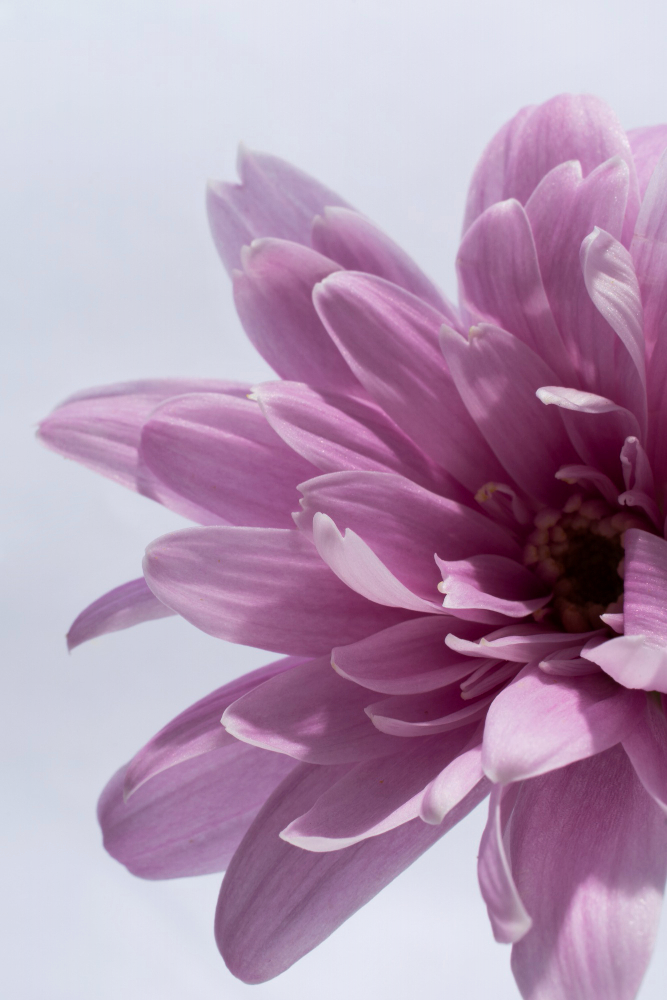

In [33]:
rgb_array = np.dstack((torch.clamp(R_U @ R_D @ R_V.T, 0, 255).to(torch.uint8).cpu().numpy(),
                       torch.clamp(G_U @ G_D @ G_V.T, 0, 255).to(torch.uint8).cpu().numpy(),
                       torch.clamp(B_U @ B_D @ B_V.T, 0, 255).to(torch.uint8).cpu().numpy()))
rgb_img = Image.fromarray(rgb_array, mode="RGB")
rgb_img